In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

# Display all columns
pd.set_option('display.max_columns', None)

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

In [6]:
df = pd.read_excel('Dataset for Data Analytics.xlsx')

In [7]:
df.head()

,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice
0,ORD200000,2023-01-04,C72649,Monitor,5,570.62,928 Main St,Debit Card,Shipped,TRK37947903,7,SAVE10,Instagram,2853.10
1,ORD200001,2024-08-23,C75739,Phone,2,151.35,823 Main St,Online,Shipped,TRK91186779,3,SAVE10,Referral,302.70
2,ORD200002,2024-02-27,C81728,Tablet,5,550.68,512 Main St,Credit Card,Cancelled,TRK42903982,8,FREESHIP,Email,2753.40
3,ORD200003,2023-10-15,C33540,Chair,1,273.19,275 Main St,Debit Card,Returned,TRK62788070,5,SAVE10,Facebook,273.19
4,ORD200004,2025-05-08,C81840,Printer,4,626.01,668 Main St,Online,Delivered,TRK29241424,8,SAVE10,Email,2504.04


In [8]:
df.tail()

,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice
1195,ORD201195,2024-06-20,C21126,Desk,1,107.04,392 Main St,Credit Card,Cancelled,TRK38009181,6,FREESHIP,Google,107.04
1196,ORD201196,2024-03-04,C20095,Monitor,2,662.53,778 Main St,Online,Cancelled,TRK69207593,5,NaN,Facebook,1325.06
1197,ORD201197,2023-07-13,C79674,Tablet,2,436.84,275 Main St,Online,Delivered,TRK88039356,2,FREESHIP,Instagram,873.68
1198,ORD201198,2024-08-22,C64753,Chair,4,262.52,509 Main St,Debit Card,Cancelled,TRK71683331,4,WINTER15,Instagram,1050.08
1199,ORD201199,2023-06-11,C57502,Tablet,4,560.58,201 Main St,Gift Card,Returned,TRK51116746,6,SAVE10,Referral,2242.32


In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   OrderID          1200 non-null   str           
 1   Date             1200 non-null   datetime64[us]
 2   CustomerID       1200 non-null   str           
 3   Product          1200 non-null   str           
 4   Quantity         1200 non-null   int64         
 5   UnitPrice        1200 non-null   float64       
 6   ShippingAddress  1200 non-null   str           
 7   PaymentMethod    1200 non-null   str           
 8   OrderStatus      1200 non-null   str           
 9   TrackingNumber   1200 non-null   str           
 10  ItemsInCart      1200 non-null   int64         
 11  CouponCode       891 non-null    str           
 12  ReferralSource   1200 non-null   str           
 13  TotalPrice       1200 non-null   float64       
dtypes: datetime64[us](1), float64(2), int64(2), str(9)


In [10]:
df.isnull().sum()

OrderID              0
Date                 0
CustomerID           0
Product              0
Quantity             0
UnitPrice            0
ShippingAddress      0
PaymentMethod        0
OrderStatus          0
TrackingNumber       0
ItemsInCart          0
CouponCode         309
ReferralSource       0
TotalPrice           0
dtype: int64

In [11]:
for col in df.columns:
    df[col]=df[col].fillna(df[col].mode()[0])


In [12]:
df.isnull().sum()

OrderID            0
Date               0
CustomerID         0
Product            0
Quantity           0
UnitPrice          0
ShippingAddress    0
PaymentMethod      0
OrderStatus        0
TrackingNumber     0
ItemsInCart        0
CouponCode         0
ReferralSource     0
TotalPrice         0
dtype: int64

In [15]:
df.duplicated().sum()

np.int64(0)

In [16]:
categorical_cols = df.select_dtypes(include="object").columns

for col in categorical_cols:
    print("=" * 50)
    print(col)
    print(df[col].unique())

OrderID
<StringArray>
['ORD200000', 'ORD200001', 'ORD200002', 'ORD200003', 'ORD200004', 'ORD200005',
 'ORD200006', 'ORD200007', 'ORD200008', 'ORD200009',
 ...
 'ORD201190', 'ORD201191', 'ORD201192', 'ORD201193', 'ORD201194', 'ORD201195',
 'ORD201196', 'ORD201197', 'ORD201198', 'ORD201199']
Length: 1200, dtype: str
CustomerID
<StringArray>
['C72649', 'C75739', 'C81728', 'C33540', 'C81840', 'C37249', 'C83492',
 'C41460', 'C26817', 'C31946',
 ...
 'C46886', 'C44148', 'C72007', 'C45104', 'C29885', 'C21126', 'C20095',
 'C79674', 'C64753', 'C57502']
Length: 1189, dtype: str
Product
<StringArray>
['Monitor', 'Phone', 'Tablet', 'Chair', 'Printer', 'Laptop', 'Desk']
Length: 7, dtype: str
ShippingAddress
<StringArray>
['928 Main St', '823 Main St', '512 Main St', '275 Main St', '668 Main St',
 '934 Main St', '986 Main St', '706 Main St', '904 Main St', '102 Main St',
 ...
 '105 Main St', '374 Main St', '777 Main St', '676 Main St', '924 Main St',
 '149 Main St', '754 Main St', '392 Main St', '50

In [17]:
df.nunique()


OrderID            1200
Date                671
CustomerID         1189
Product               7
Quantity              5
UnitPrice          1193
ShippingAddress     655
PaymentMethod         5
OrderStatus           5
TrackingNumber     1200
ItemsInCart          10
CouponCode            3
ReferralSource        5
TotalPrice         1195
dtype: int64

In [18]:
print("Number of Rows:", df.shape[0])
print("Number of Columns:", df.shape[1])

Number of Rows: 1200
Number of Columns: 14


In [19]:
df.describe()

,Date,Quantity,UnitPrice,ItemsInCart,TotalPrice
count,1200,1200.000000,1200.000000,1200.000000,1200.000000
mean,2024-03-22 16:58:48,2.945833,356.412750,5.485000,1053.968300
min,2023-01-01 00:00:00,1.000000,11.390000,1.000000,11.390000
25%,2023-08-03 18:00:00,2.000000,186.062500,4.000000,410.520000
50%,2024-03-23 00:00:00,3.000000,364.210000,5.000000,823.615000
75%,2024-11-08 12:00:00,4.000000,521.570000,7.000000,1578.475000
max,2025-06-30 00:00:00,5.000000,699.930000,10.000000,3456.400000
std,NaN,1.407557,197.177146,2.281983,819.856558


In [20]:
df.select_dtypes(include=["int64", "float64"]).corr()

,Quantity,UnitPrice,ItemsInCart,TotalPrice
Quantity,1.000000,0.014553,0.650061,0.615251
UnitPrice,0.014553,1.000000,0.000602,0.717081
ItemsInCart,0.650061,0.000602,1.000000,0.392540
TotalPrice,0.615251,0.717081,0.392540,1.000000


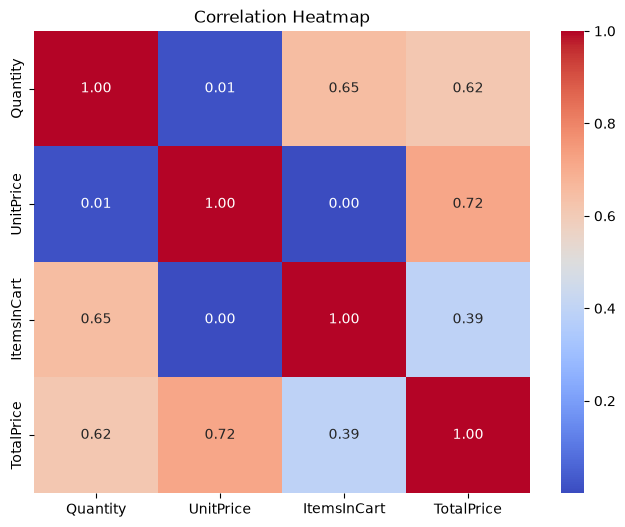

In [21]:
plt.figure(figsize=(8,6))

sns.heatmap(
    df.select_dtypes(include=["int64","float64"]).corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.show()

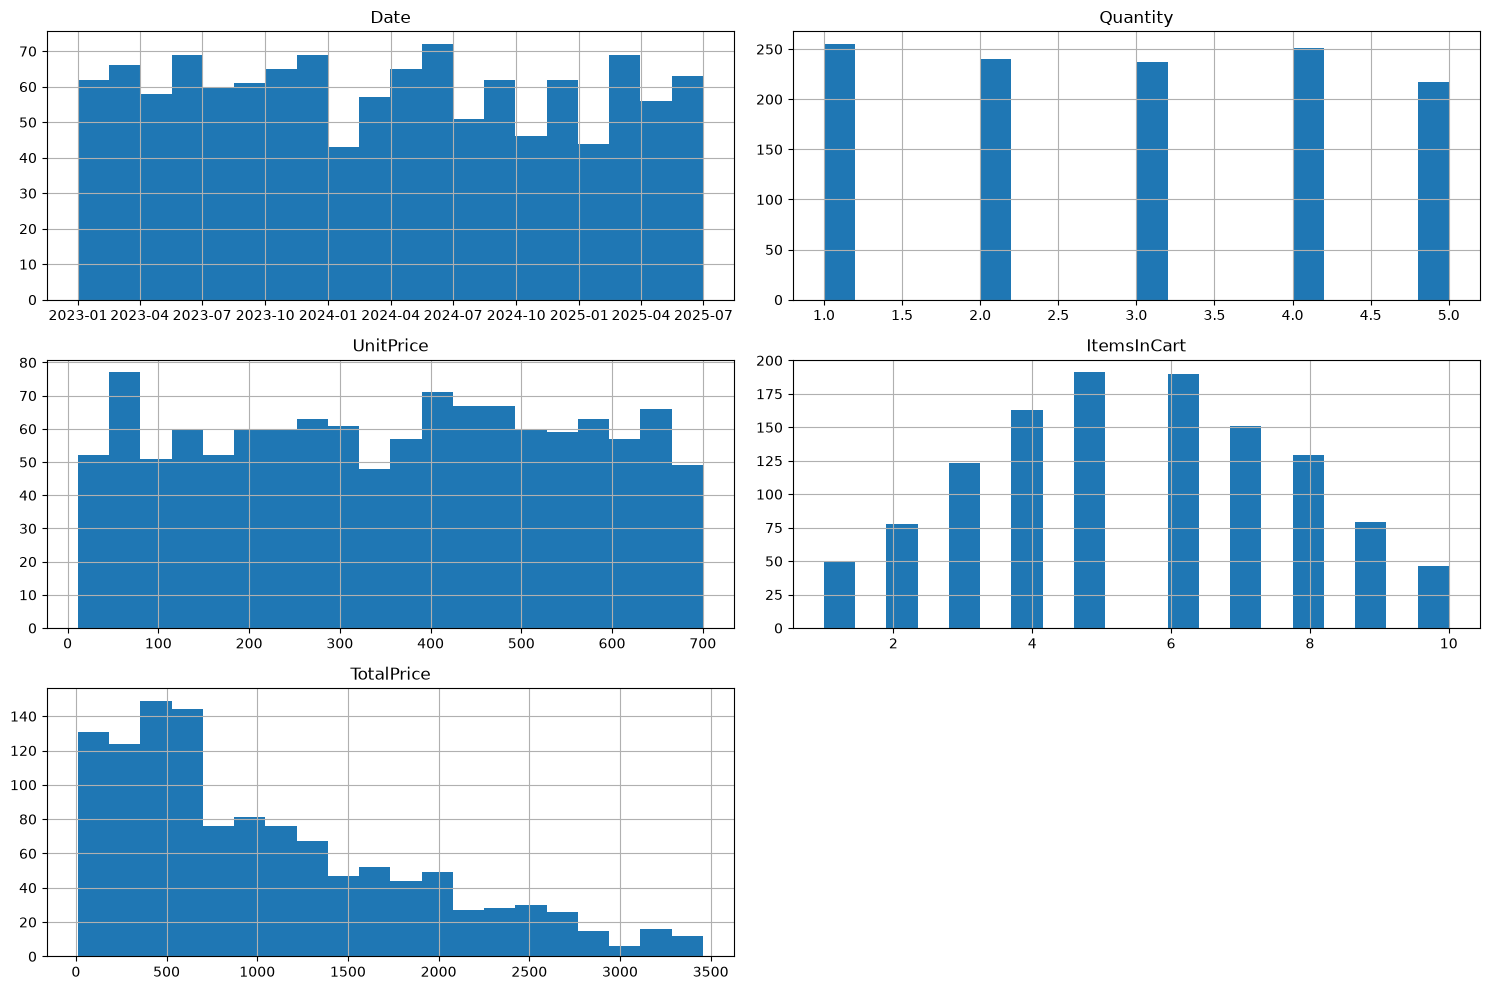

In [22]:
df.hist(figsize=(15,10), bins=20)

plt.tight_layout()
plt.show()

Orders Over time

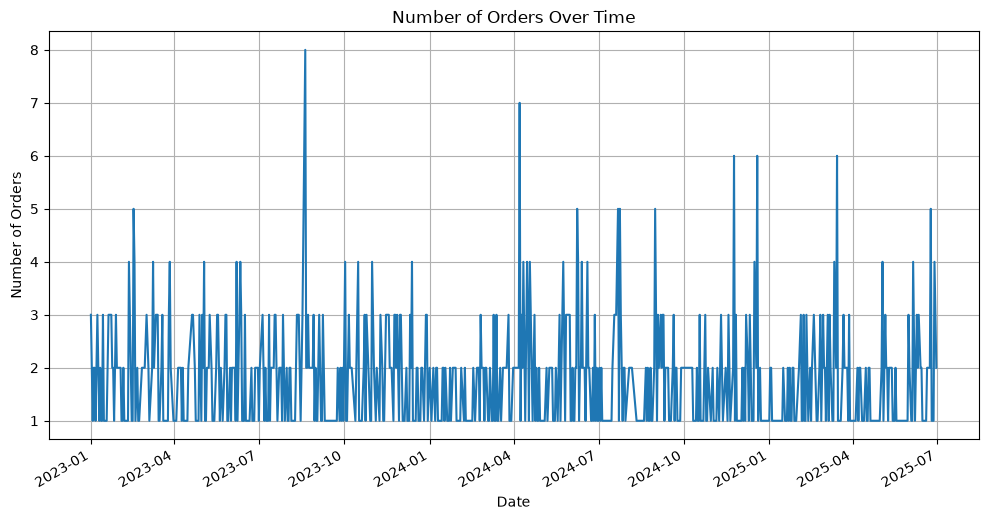

In [24]:
plt.figure(figsize=(12,6))

df.groupby("Date")["OrderID"].count().plot()

plt.title("Number of Orders Over Time")
plt.xlabel("Date")
plt.ylabel("Number of Orders")
plt.grid(True)

plt.show()

Order volume fluctuates over time.
Certain dates have noticeably higher order activity, indicating peak demand periods.

Top selling products

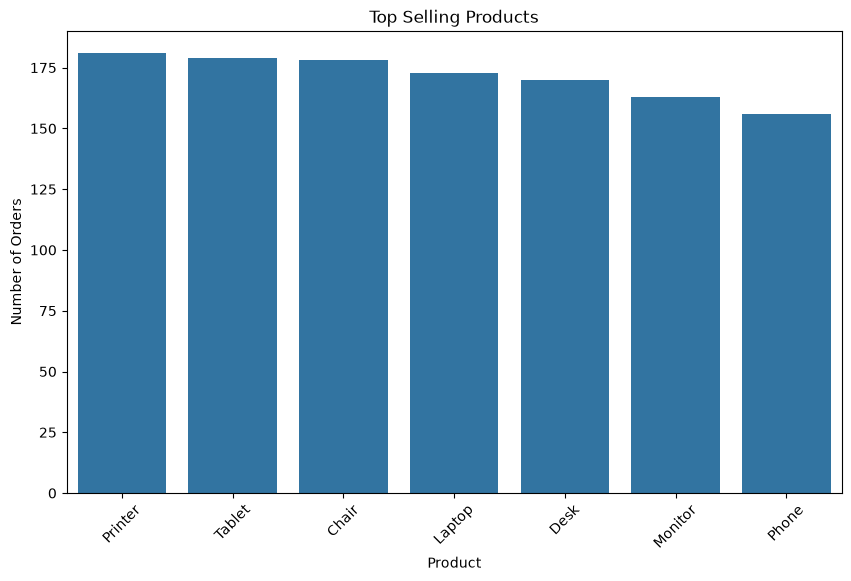

In [25]:
plt.figure(figsize=(10,6))

sns.countplot(
    data=df,
    x="Product",
    order=df["Product"].value_counts().index
)

plt.xticks(rotation=45)
plt.title("Top Selling Products")
plt.xlabel("Product")
plt.ylabel("Number of Orders")

plt.show()

A few products account for the majority of sales.
These products should be prioritized for inventory management and promotions.

Revenue by Product

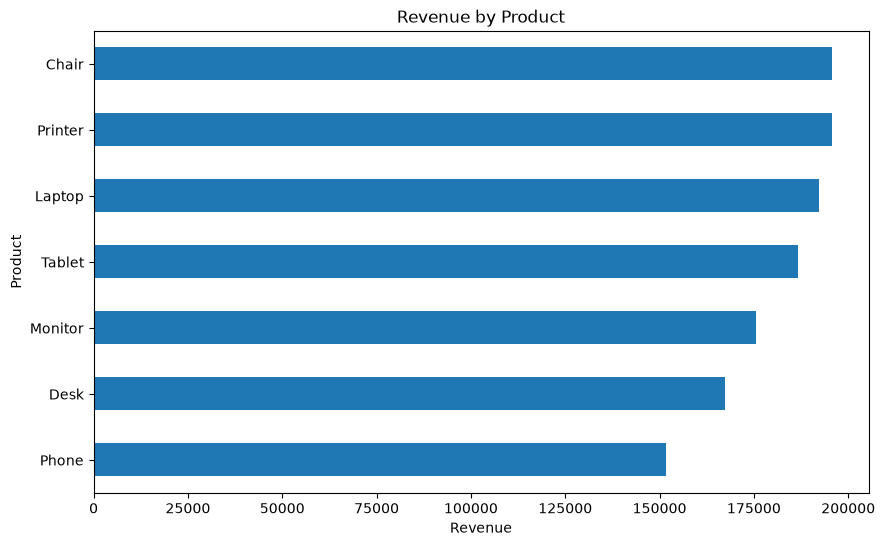

In [26]:
plt.figure(figsize=(10,6))

df.groupby("Product")["TotalPrice"].sum().sort_values().plot(kind="barh")

plt.title("Revenue by Product")
plt.xlabel("Revenue")
plt.ylabel("Product")

plt.show()

Some products generate significantly higher revenue than others.
High-revenue products should receive focused marketing efforts

Quantity VS Total price

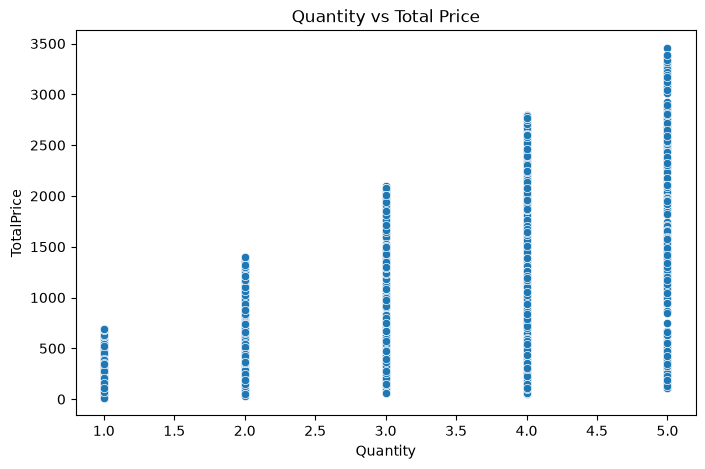

In [27]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x="Quantity",
    y="TotalPrice"
)

plt.title("Quantity vs Total Price")

plt.show()

Most orders fall within a moderate price range.A few high-value purchases indicate opportunities for premium product offerings.